# Final Portfolio Outputs

## tl;dr

This project identifies public EV charging gaps and first-phase infrastructure opportunities across Barrow, Clarke, Gwinnett, Hall, Jackson, Oconee, and Walton counties.

The analysis combines:

- the existing DOE Alternative Fuels Data Center inventory,
- 2020–2024 ACS demographic and housing indicators,
- highway proximity and FHWA traffic volume,
- mapped destination opportunities,
- FEMA flood hazards, USFWS wetlands, and USGS protected lands,
- EV-adoption and public-port demand scenarios, and
- ranked Level 2 and DC fast recommendations.

The final recommendations are planning concepts—not construction-ready engineering designs.

## Context & Methods

### Research question

> Where should additional public EV charging stations be installed, what charging speed and connector type should each location use, and how many charging ports are appropriate for an initial deployment?

### Analytical workflow

1. Inventory existing public stations, charging levels, ports, and connectors.
2. Measure demographic demand and public-charging dependence.
3. Identify community and DC fast-charging access gaps.
4. Model Level 2 destination and DC corridor suitability separately.
5. Screen Level 2 candidates for environmental constraints.
6. Estimate port requirements under three adoption scenarios.
7. Rank a practical first-phase deployment with expansion capacity.

### Interpretation

Scores are relative prioritization measures within the seven-county study area. Port-demand totals are scenario estimates benchmarked to NREL's national public-charging requirements. Recommended points require parcel, ownership, zoning, utility, and field verification.

## Data

### 1. Load final analytical products

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
MAP_DIR = PROJECT_ROOT / "maps"
BOUNDARY_DIR = PROJECT_ROOT / "data" / "raw" / "boundaries"
ROAD_DIR = PROJECT_ROOT / "data" / "raw" / "roads"
PROJECTED_CRS = "EPSG:26916"

acs = gpd.read_file(SPATIAL_DIR / "acs_ev_demand_block_groups.gpkg")
stations = gpd.read_file(SPATIAL_DIR / "existing_ev_charging_units.gpkg")
study_area = gpd.read_file(SPATIAL_DIR / "study_area_counties.gpkg")
interstates = gpd.read_file(
    ROAD_DIR / "fhwa_hpms_interstates_study_area.gpkg"
)
us_highways = gpd.read_file(
    ROAD_DIR / "fhwa_hpms_us_highways_study_area.gpkg"
)
places = gpd.read_file(BOUNDARY_DIR / "tl_2025_13_place.zip")
recommendations = gpd.read_file(
    SPATIAL_DIR / "ranked_ev_charging_recommendations.gpkg"
)
scenario_totals = pd.read_csv(
    TABLE_DIR / "charging_port_demand_scenario_totals.csv"
)
phase_summary = pd.read_csv(TABLE_DIR / "first_phase_port_gap_summary.csv")

stations = stations.drop_duplicates("ID").copy()
for field in ["EV Level2 EVSE Num", "EV DC Fast Count"]:
    stations[field] = pd.to_numeric(stations[field], errors="coerce").fillna(0)

assert recommendations["source_geography"].notna().all()
assert stations["ID"].is_unique
assert acs["GEOID"].is_unique

print(f"Study-area population: {acs['population'].sum():,.0f}")
print(f"Census block groups analyzed: {len(acs):,}")
print(f"Existing public charging stations: {len(stations):,}")
print(f"Existing Level 2 ports: {stations['EV Level2 EVSE Num'].sum():,.0f}")
print(f"Existing DC fast ports: {stations['EV DC Fast Count'].sum():,.0f}")
print(f"First-phase recommendations: {len(recommendations):,}")

Study-area population: 1,643,685
Census block groups analyzed: 926
Existing public charging stations: 272
Existing Level 2 ports: 580
Existing DC fast ports: 282
First-phase recommendations: 28


## Results

### 2. Executive scorecard

In [2]:
moderate = scenario_totals.loc[
    scenario_totals["scenario"] == "Moderate (12%)"
].iloc[0]
level2_recs = recommendations.loc[
    recommendations["recommendation_type"] == "Level 2 destination"
]
dc_recs = recommendations.loc[
    recommendations["recommendation_type"] == "DC fast planning zone"
]

scorecard = pd.DataFrame({
    "Portfolio metric": [
        "Study-area population",
        "Existing public stations",
        "Existing Level 2 ports",
        "Existing DC fast ports",
        "Moderate-scenario projected EV households",
        "Moderate-scenario additional Level 2 ports",
        "Moderate-scenario additional DC fast ports",
        "First-phase Level 2 locations",
        "First-phase DC fast planning zones",
        "First-phase initial ports",
        "First-phase expansion capacity",
    ],
    "Value": [
        f"{acs['population'].sum():,.0f}",
        f"{len(stations):,.0f}",
        f"{stations['EV Level2 EVSE Num'].sum():,.0f}",
        f"{stations['EV DC Fast Count'].sum():,.0f}",
        f"{moderate['projected_evs']:,.0f}",
        f"{moderate['additional_l2_ports']:,.0f}",
        f"{moderate['additional_dc_fast_ports']:,.0f}",
        f"{len(level2_recs):,.0f}",
        f"{len(dc_recs):,.0f}",
        f"{recommendations['initial_ports'].sum():,.0f}",
        f"{recommendations['expansion_ports'].sum():,.0f}",
    ],
})
scorecard

,Portfolio metric,Value
0,Study-area population,"1,643,685"
1,Existing public stations,272
2,Existing Level 2 ports,580
3,Existing DC fast ports,282
4,Moderate-scenario projected EV households,"181,260"
5,Moderate-scenario additional Level 2 ports,"5,592"
6,Moderate-scenario additional DC fast ports,771
7,First-phase Level 2 locations,16
8,First-phase DC fast planning zones,12
9,First-phase initial ports,176


### 3. Final network-plan map

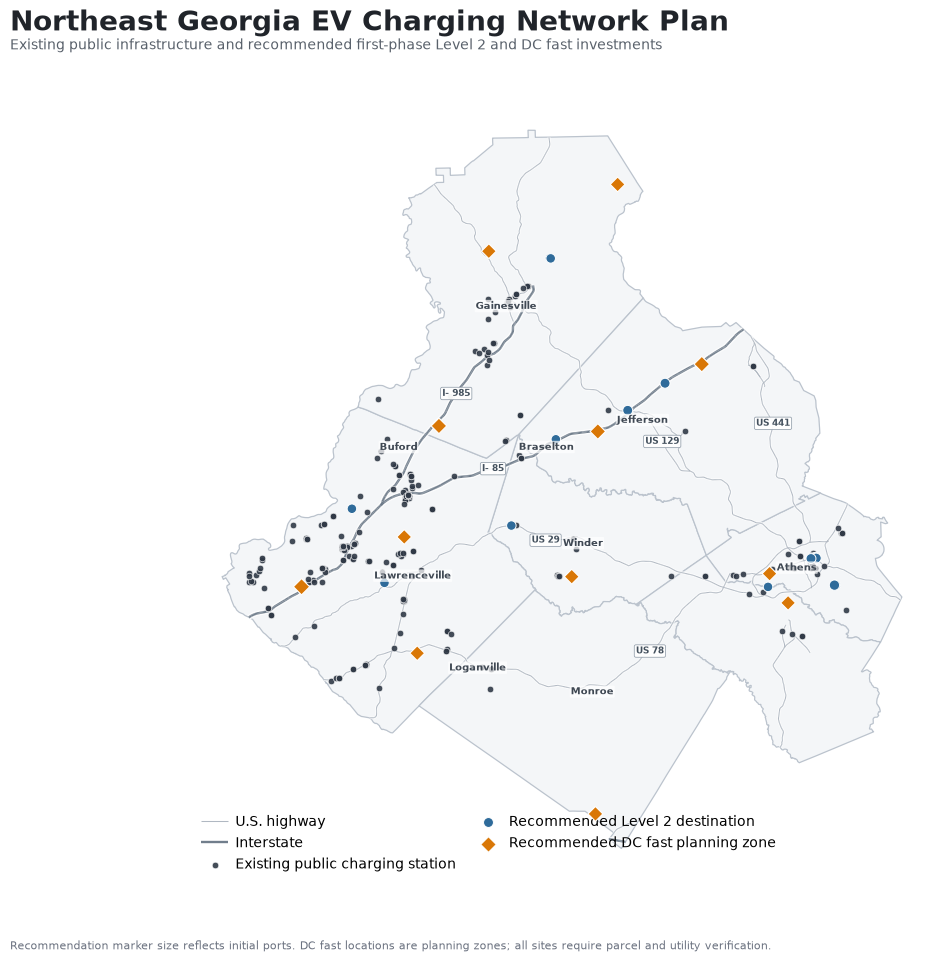

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\final_ev_charging_network_plan.png


In [3]:
area_map = study_area.to_crs(PROJECTED_CRS)
station_map = stations.to_crs(PROJECTED_CRS)
recommendation_map = recommendations.to_crs(PROJECTED_CRS)
interstate_map = interstates.to_crs(PROJECTED_CRS)
us_highway_map = us_highways.to_crs(PROJECTED_CRS)
place_map = places.to_crs(PROJECTED_CRS)
study_union = area_map.geometry.union_all()

station_map = station_map.loc[
    station_map.geometry.intersects(study_union)
].copy()
interstate_map = interstate_map.loc[
    interstate_map.geometry.intersects(study_union)
].copy()
us_highway_map = us_highway_map.loc[
    us_highway_map.geometry.intersects(study_union)
].copy()
place_map = place_map.loc[
    place_map.geometry.representative_point().within(study_union)
].copy()

level2_map = recommendation_map.loc[
    recommendation_map["recommendation_type"] == "Level 2 destination"
]
dc_map = recommendation_map.loc[
    recommendation_map["recommendation_type"] == "DC fast planning zone"
]

fig, ax = plt.subplots(figsize=(12, 10), facecolor="white")
area_map.plot(
    ax=ax, color="#F4F6F8", edgecolor="#BBC3CD", linewidth=0.9,
    zorder=1,
)
us_highway_map.plot(
    ax=ax, color="white", linewidth=2.0, alpha=0.95, zorder=2
)
us_highway_map.plot(
    ax=ax, color="#A8B1BC", linewidth=0.75, alpha=0.9,
    label="U.S. highway", zorder=3,
)
interstate_map.plot(
    ax=ax, color="white", linewidth=3.6, alpha=1.0, zorder=4
)
interstate_map.plot(
    ax=ax, color="#697786", linewidth=1.7, alpha=0.95,
    label="Interstate", zorder=5,
)
station_map.plot(
    ax=ax, color="#303946", marker="o", markersize=22,
    edgecolor="white", linewidth=0.45, alpha=0.9,
    label="Existing public charging station", zorder=6,
)
level2_map.plot(
    ax=ax, color="#2F6B9A", marker="o",
    markersize=35 + level2_map["initial_ports"] * 2,
    edgecolor="white", linewidth=0.7,
    label="Recommended Level 2 destination", zorder=7,
)
dc_map.plot(
    ax=ax, color="#D97706", marker="D",
    markersize=45 + dc_map["initial_ports"] * 3,
    edgecolor="white", linewidth=0.8,
    label="Recommended DC fast planning zone", zorder=8,
)

city_names = {
    "Athens-Clarke County unified government (balance)": "Athens",
    "Braselton": "Braselton",
    "Buford": "Buford",
    "Gainesville": "Gainesville",
    "Jefferson": "Jefferson",
    "Lawrenceville": "Lawrenceville",
    "Loganville": "Loganville",
    "Monroe": "Monroe",
    "Winder": "Winder",
}
for source_name, display_name in city_names.items():
    city = place_map.loc[place_map["NAME"] == source_name]
    if city.empty:
        continue
    point = city.geometry.iloc[0].representative_point()
    ax.text(
        point.x, point.y, display_name,
        ha="center", va="center", fontsize=7.2,
        color="#3F4853", weight="bold", zorder=9,
        bbox={
            "boxstyle": "round,pad=0.10",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72,
        },
    )

def add_route_labels(roads, route_numbers, prefix):
    for route_number in route_numbers:
        segments = roads.loc[
            pd.to_numeric(roads["route_number"], errors="coerce")
            == route_number
        ]
        if segments.empty:
            continue
        point = segments.geometry.union_all().representative_point()
        ax.text(
            point.x, point.y, f"{prefix} {route_number}",
            ha="center", va="center", fontsize=6.5, weight="bold",
            color="#43505D", zorder=10,
            bbox={
                "boxstyle": "round,pad=0.18",
                "facecolor": "white",
                "edgecolor": "#8C98A5",
                "linewidth": 0.55,
                "alpha": 0.95,
            },
        )

add_route_labels(interstate_map, [85, 985], "I-")
add_route_labels(us_highway_map, [23, 29, 78, 129, 441], "US")

fig.suptitle(
    "Northeast Georgia EV Charging Network Plan",
    x=0.04, y=0.965, ha="left",
    fontsize=20, weight="bold", color="#20242A",
)
fig.text(
    0.04, 0.925,
    "Existing public infrastructure and recommended first-phase Level 2 and DC fast investments",
    ha="left", fontsize=10, color="#59616B",
)
ax.legend(
    frameon=False, loc="lower left", ncol=2,
    columnspacing=1.3, handletextpad=0.5,
)
ax.set_axis_off()
fig.text(
    0.04, 0.025,
    "Recommendation marker size reflects initial ports. DC fast locations are planning zones; all sites require parcel and utility verification.",
    fontsize=8, color="#6B7280",
)
fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.09)

final_map_path = MAP_DIR / "final_ev_charging_network_plan.png"
fig.savefig(
    final_map_path, dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved:", final_map_path)

### 4. First-phase port investment by county

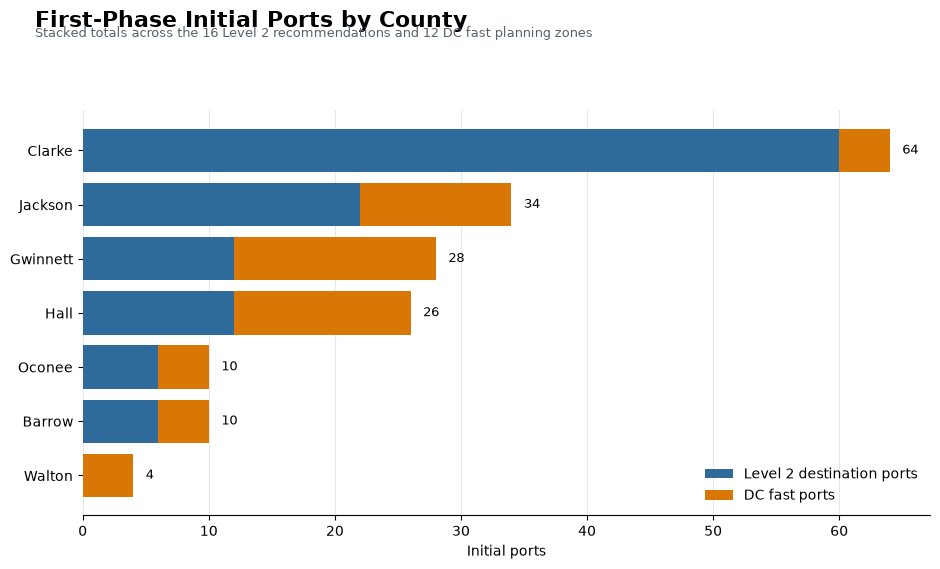

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\figures\first_phase_ports_by_county.png


In [4]:
county_phase = (
    recommendations.groupby(
        ["county_name", "recommendation_type"], as_index=False
    )["initial_ports"].sum()
    .pivot(
        index="county_name",
        columns="recommendation_type",
        values="initial_ports",
    )
    .fillna(0)
)
for column in ["Level 2 destination", "DC fast planning zone"]:
    if column not in county_phase:
        county_phase[column] = 0
county_phase["total"] = county_phase.sum(axis=1)
county_phase = county_phase.sort_values("total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
y = np.arange(len(county_phase))
level2_values = county_phase["Level 2 destination"]
dc_values = county_phase["DC fast planning zone"]

ax.barh(
    y, level2_values, color="#2F6B9A",
    label="Level 2 destination ports",
)
ax.barh(
    y, dc_values, left=level2_values, color="#D97706",
    label="DC fast ports",
)
for index, total in enumerate(county_phase["total"]):
    ax.text(total + 1, index, f"{int(total)}", va="center", fontsize=9)

ax.set_yticks(y, county_phase.index)
ax.set_xlabel("Initial ports")
fig.suptitle(
    "First-Phase Initial Ports by County",
    x=0.08, y=0.97, ha="left", fontsize=16, weight="bold",
)
fig.text(
    0.08, 0.925,
    "Stacked totals across the 16 Level 2 recommendations and 12 DC fast planning zones",
    fontsize=9, color="#59616B",
)
ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout(rect=[0.04, 0.03, 0.99, 0.89])

county_chart_path = FIGURE_DIR / "first_phase_ports_by_county.png"
fig.savefig(
    county_chart_path, dpi=300, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved:", county_chart_path)

### 5. Portfolio recommendation table

In [5]:
portfolio_table = recommendations[[
    "overall_rank", "location_label", "county_name",
    "recommendation_type", "initial_ports", "expansion_ports",
    "power_recommendation", "connector_mix", "site_status",
]].sort_values("overall_rank")

portfolio_table.head(12)

,overall_rank,location_label,county_name,recommendation_type,initial_ports,expansion_ports,power_recommendation,connector_mix,site_status
0,1,Gwinnett zone 3331,Gwinnett,DC fast planning zone,8,16,250–350 kW DC fast,CCS1 + J3400/NACS,Planning zone; exact parcel and utility verifi...
1,2,Hall zone 6073,Hall,DC fast planning zone,6,12,150–250 kW DC fast,CCS1 + J3400/NACS,Planning zone; exact parcel and utility verifi...
2,3,Gwinnett zone 7542,Gwinnett,DC fast planning zone,4,8,150–250 kW DC fast,CCS1 + J3400/NACS,Planning zone; exact parcel and utility verifi...
3,4,Clarke L2-0020,Clarke,Level 2 destination,10,14,11.5–19.2 kW AC Level 2,J1772 + J3400/NACS,Mapped parking opportunity; parcel verificatio...
4,5,Clarke L2-0021,Clarke,Level 2 destination,10,14,11.5–19.2 kW AC Level 2,J1772 + J3400/NACS,Mapped parking opportunity; parcel verificatio...
5,6,Jackson zone 2002,Jackson,DC fast planning zone,6,12,150–250 kW DC fast,CCS1 + J3400/NACS,Planning zone; exact parcel and utility verifi...
6,7,Jackson zone 1051,Jackson,DC fast planning zone,6,12,150–250 kW DC fast,CCS1 + J3400/NACS,Planning zone; exact parcel and utility verifi...
7,8,Clarke L2-0015,Clarke,Level 2 destination,8,12,11.5–19.2 kW AC Level 2,J1772 + J3400/NACS,Mapped parking opportunity; parcel verificatio...
8,9,Clarke L2-0016,Clarke,Level 2 destination,8,12,11.5–19.2 kW AC Level 2,J1772 + J3400/NACS,Mapped parking opportunity; parcel verificatio...
9,10,Clarke L2-0024,Clarke,Level 2 destination,8,12,11.5–19.2 kW AC Level 2,J1772 + J3400/NACS,Mapped parking opportunity; parcel verificatio...


### 6. Save final tables and validate presentation outputs

In [6]:
scorecard_path = TABLE_DIR / "portfolio_executive_scorecard.csv"
portfolio_table_path = TABLE_DIR / "portfolio_recommendation_table.csv"
county_phase_path = TABLE_DIR / "first_phase_ports_by_county.csv"

scorecard.to_csv(scorecard_path, index=False)
portfolio_table.to_csv(portfolio_table_path, index=False)
county_phase.reset_index().to_csv(county_phase_path, index=False)

assert len(recommendations) == 28
assert len(level2_recs) == 16
assert len(dc_recs) == 12
assert recommendations["overall_rank"].is_unique
assert recommendations["source_geography"].notna().all()
assert set(recommendations["county_name"]) == set(study_area["NAME"])
assert int(recommendations["initial_ports"].sum()) == 176
assert int(recommendations["expansion_ports"].sum()) == 298
assert all(path.exists() for path in [
    final_map_path, county_chart_path, scorecard_path,
    portfolio_table_path, county_phase_path,
])

print("All recommendation-count, county-coverage, ranking, port-total, and output checks passed.")
print("Saved:", scorecard_path)
print("Saved:", portfolio_table_path)
print("Saved:", county_phase_path)

All recommendation-count, county-coverage, ranking, port-total, and output checks passed.
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\portfolio_executive_scorecard.csv
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\portfolio_recommendation_table.csv
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\first_phase_ports_by_county.csv


## Takeaways

1. **The existing network is concentrated.** Infrastructure is strongest in Gwinnett and the larger urban centers, while several outer counties have relatively limited public charging.
2. **Destination and corridor charging solve different problems.** Level 2 recommendations support longer dwell times and community access; DC fast planning zones support high-volume corridors and regional travel.
3. **The first phase is intentionally smaller than the modeled regional deficit.** It provides 176 initial ports with physical expansion capacity to 298 ports, while the moderate-adoption scenario indicates a much larger distributed network will ultimately be necessary.
4. **Connector compatibility is forward-looking.** New Level 2 sites use J1772 and J3400/NACS; new DC fast sites use CCS1 and J3400/NACS.
5. **Site verification remains essential.** Environmental screening reduces obvious conflicts but does not replace parcel, title, zoning, utility, engineering, ADA, safety, or community review.

### Portfolio conclusion

This analysis demonstrates a complete GIS planning workflow: data acquisition, cleaning, demographic modeling, proximity and corridor analysis, environmental screening, multi-criteria scoring, scenario modeling, cartographic design, and practical infrastructure recommendations.